In [1]:
import numpy as np

In [3]:

k=3
data=[
[1.0,2.0,0],
[1.5,1.8,0],
[5.0,8.0,1],
[6.0,9.0,1],
[1.0,0.6,0],
[2.0,1.0,0],
[5.0,5.0,0],
[6.0,1.0,1],
]

In [4]:

#split dataset into features and labels
x=[[row[0], row[1]] for row in data]
y=[row[2] for row in data]

In [7]:
x_train = np.array(x)
y_train = np.array(y)

In [10]:
x_train

array([[1. , 2. ],
       [1.5, 1.8],
       [5. , 8. ],
       [6. , 9. ],
       [1. , 0.6],
       [2. , 1. ],
       [5. , 5. ],
       [6. , 1. ]])

In [12]:
y_train

array([0, 0, 1, 1, 0, 0, 0, 1])

In [16]:
def euclidean_distance(x1,x2):
    #Calculate Euclidean distance
    return np.sqrt(np.sum((np.array(x1)-np.array(x2)) ** 2))


In [34]:
def distance(x_test):
    distances = [euclidean_distance(x_test, x ) for x in x_train]
    return distances

In [46]:
def getIndecies(distance):
    return np.argsort(distances) #Sort values but return indexes

In [38]:
def predict(X):
    prediction = [distance(x) for x in X]
    return prediction

In [40]:
def getLabels(indices):
    return[y_train[i] for i in indices]

In [42]:
test_point = np.array([[5.0,7.0]])
distances = predict(test_point)
distances

[[6.4031242374328485,
  6.268173577685928,
  1.0,
  2.23606797749979,
  7.547184905645284,
  6.708203932499369,
  2.0,
  6.082762530298219]]

In [44]:
np.sort(distances)[0][0:3]

array([1.        , 2.        , 2.23606798])

In [58]:
sortedIndecies = getIndecies(distances)
sortedIndecies

array([[2, 6, 3, 7, 1, 0, 5, 4]], dtype=int64)

In [50]:
sortedDistance = np.sort(distances)
sortedDistance

array([[1.        , 2.        , 2.23606798, 6.08276253, 6.26817358,
        6.40312424, 6.70820393, 7.54718491]])

In [60]:
sortedLabels = getLabels(sortedIndecies)
sortedLabels

[array([1, 0, 1, 1, 0, 0, 0, 0])]

## Actual Implementation

## import libraries

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Create dataset randomly

In [141]:
#set randon seed from reproducibility
np.random.seed(42) #random numbers which will be generated should be reproducible 

#Create a synthetic dataset
#Class 0
class_0 = np.random.randn(400,2)+np.array([1,1]) #uplift to 1 
# Class 1
class_1 = np.random.randn(600,2)+np.array([5,5])

#Combine classes into single dataset
X = np.vstack((class_0, class_1))
y = np.array([0]*400 + [1]*600)

#Create a dataframe for easier handling
df = pd.DataFrame(X, columns=['Feature 1', 'Feature 2'])
df['Target'] = y

#Display the first few rows of dataset
df.head()

,Feature 1,Feature 2,Target
0,1.496714,0.861736,0
1,1.647689,2.523030,0
2,0.765847,0.765863,0
3,2.579213,1.767435,0
4,0.530526,1.542560,0


In [143]:
df

,Feature 1,Feature 2,Target
0,1.496714,0.861736,0
1,1.647689,2.523030,0
2,0.765847,0.765863,0
3,2.579213,1.767435,0
4,0.530526,1.542560,0
...,...,...,...
995,5.800410,5.754291,1
996,6.188913,5.708304,1
997,5.351448,6.070150,1
998,4.973479,4.118125,1


## Visualization

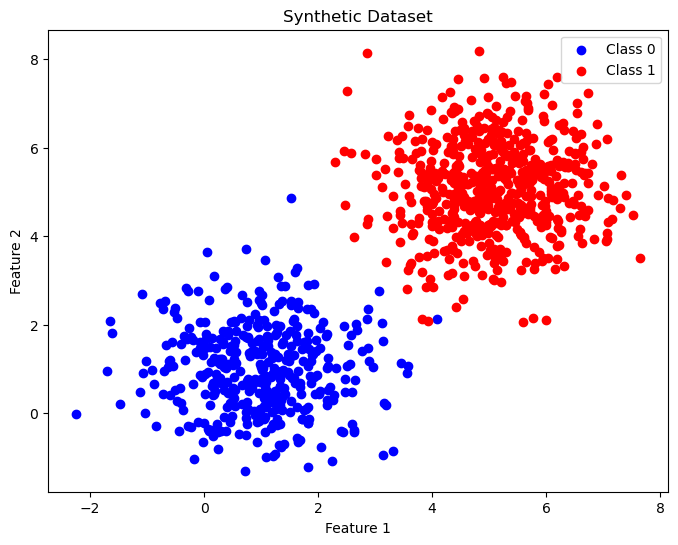

In [145]:
plt.figure(figsize=(8,6))
plt.scatter(df[df['Target']==0]['Feature 1'], df[df['Target']==0]['Feature 2'], color='blue', label='Class 0')
plt.scatter(df[df['Target']==1]['Feature 1'], df[df['Target']==1]['Feature 2'], color='red', label='Class 1')
plt.title('Synthetic Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

## Implement KNN Algorithm

In [147]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [149]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3)

In [151]:
knn = KNeighborsClassifier(n_neighbors=5) #K Value
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [153]:
y_pred = knn.predict(X_test)

In [155]:
#Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[124   1]
 [  0 175]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       125
           1       0.99      1.00      1.00       175

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300

